# Computational Benchmarks: JAXOperator vs SciPySparseOperator

This notebook quantifies the memory and runtime advantages of the Phase 2
`JAXOperator` (compact trace storage + JAX JIT) over the Phase 1
`SciPySparseOperator` (full CSR sparse matrix), and compares convergence
of `JAXProximalSolver` (FISTA) against `SpectralSolver` (LSQR).

**Audience:** developers and contributors evaluating Phase 2 design choices.

In [1]:
from __future__ import annotations

import time
import timeit
import tracemalloc
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import spectrex
from spectrex import (
    EigenspectraBasis,
    InstrumentConfig,
    JAXOperator,
    JAXProximalSolver,
    NoiseModel,
    SciPySparseOperator,
    SpectralSolver,
)

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path.cwd()
REPO = NOTEBOOK_DIR.parent
TESTDATA = REPO / 'testdata'
print(f'spectrex version: {spectrex.__version__}')


spectrex version: 0.2.1.dev3+g6e87286d0.d20260505


## Instrument Setup

In [2]:
config = InstrumentConfig.from_files(
    conf_path=TESTDATA / 'Config Files' / 'GR150R.F150W.220725.conf',
    wavelengthrange_path=TESTDATA / 'jwst_niriss_wavelengthrange_0002.asdf',
    sensitivity_dir=TESTDATA / 'SenseConfig' / 'wfss-grism-configuration',
    filter_name='F150W',
    n_wavelengths=150,
)
basis = EigenspectraBasis.from_csv(
    TESTDATA / 'eigenspectra_kurucz.csv',
    config.wavelengths,
)

# Use (500, 20) — same stamp geometry as the mock_example notebook.
# Traces land within bounds for sources across all rows.
IMAGE_SHAPE = (500, 20)
N_ROWS, N_COLS = IMAGE_SHAPE
N_PIX = N_ROWS * N_COLS
M = basis.n_components
NOISE_MODEL = NoiseModel(read_noise=5.0)
RNG = np.random.default_rng(2026)

print(f'Image shape: {IMAGE_SHAPE}, n_pix={N_PIX}')
print(f'Basis components M={M}')
print(f'n_wavelengths={len(config.wavelengths)}')
print(f'n_orders={len(config.orders)}')


Image shape: (500, 20), n_pix=10000
Basis components M=10
n_wavelengths=150
n_orders=5


## Section 1: Memory Footprint

### Analytical Model

**`SciPySparseOperator`** stores a CSR sparse matrix of shape `(N_pix, N_pix×M)`.
It builds the forward operator for *all* pixels in the image (not just K sources),
so its memory is independent of K.
- `data` array: `nnz` float64 values
- `indices` array: `nnz` int32 values
- `indptr` array: `(N_pix + 1)` int32 values = `(N_pix + 1) × 4` bytes

**Key insight:** the `indptr` array alone scales with `N_pix`, independently of K.
For NIRISS full-frame (2048×2048), `N_pix = 4,194,304` → `indptr ≈ 16 MB` per operator.

**`JAXOperator`** stores only the K requested sources:
- `trace_indices[K, n_orders, n_lambda]` int32: `K × n_orders × n_lambda × 4` bytes
- `weights[n_orders, n_lambda, M]` float32: `n_orders × n_lambda × M × 4` bytes

**Key insight:** weights are shared across all K sources — memory scales linearly with K
but is completely independent of `N_pix`.

**Analytical comparison at full NIRISS scale (K=100, n_orders=3, n_lambda=150, M=10):**
| Component | SciPySparse | JAXOperator |
|-----------|-------------|-------------|
| data/indices | K×O×L×12 ≈ 5.4 MB | K×O×L×4 ≈ 1.8 MB |
| weights | K×O×L×M×8 ≈ 36 MB | O×L×M×4 ≈ 0.18 MB |
| indptr | (N_pix+1)×4 ≈ 16 MB | — |
| **Total** | **~57 MB** | **~2 MB** |

### Measured Memory vs K

In [3]:
# SciPySparseOperator is built once — it covers ALL image pixels, K-independent.
scipy_op_mem = SciPySparseOperator.build(config, basis, IMAGE_SHAPE)
m_scipy = (
    scipy_op_mem._H.data.nbytes
    + scipy_op_mem._H.indices.nbytes
    + scipy_op_mem._H.indptr.nbytes
) / 1e6
print(f'SciPySparseOperator: {m_scipy:.2f} MB  (constant, K-independent)')
print(f'H matrix shape: {scipy_op_mem._H.shape}, nnz={scipy_op_mem._H.nnz}')


SciPySparseOperator: 117.10 MB  (constant, K-independent)
H matrix shape: (10000, 100000), nnz=9754680


In [4]:
K_GRID = [1, 2, 5, 10, 20, 50]

mem_scipy_mb = [m_scipy] * len(K_GRID)  # constant
mem_jax_mb   = []

for k in K_GRID:
    src_pos = np.column_stack([
        RNG.integers(0, N_ROWS, size=k),
        RNG.integers(0, N_COLS, size=k),
    ]).astype(np.float64)

    jax_op = JAXOperator.build(config, basis, IMAGE_SHAPE, src_pos)

    # JAX compact memory
    m_jax = (
        np.asarray(jax_op._trace_indices).nbytes
        + np.asarray(jax_op._weights).nbytes
    ) / 1e6

    mem_jax_mb.append(m_jax)
    print(f'K={k:2d}: SciPy {m_scipy:.3f} MB  JAX {m_jax:.3f} MB')


K= 1: SciPy 117.096 MB  JAX 0.033 MB
K= 2: SciPy 117.096 MB  JAX 0.036 MB
K= 5: SciPy 117.096 MB  JAX 0.045 MB
K=10: SciPy 117.096 MB  JAX 0.060 MB
K=20: SciPy 117.096 MB  JAX 0.090 MB
K=50: SciPy 117.096 MB  JAX 0.180 MB


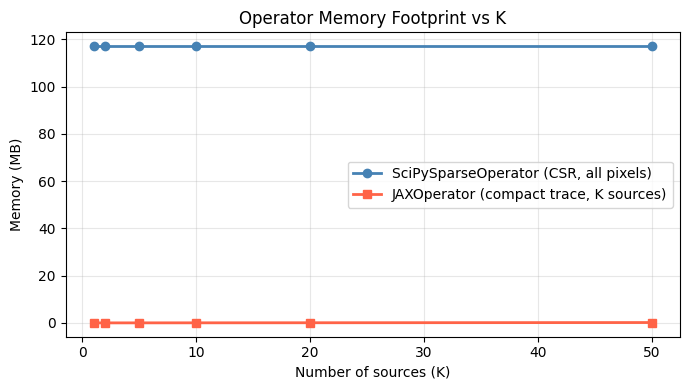


SciPy memory is flat because it always stores ALL pixel-to-source mappings.
JAXOperator memory grows linearly with K; weights are shared across sources.


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_GRID, mem_scipy_mb, 'o-', color='steelblue', label='SciPySparseOperator (CSR, all pixels)', lw=2)
ax.plot(K_GRID, mem_jax_mb,   's-', color='tomato',    label='JAXOperator (compact trace, K sources)', lw=2)
ax.set_xlabel('Number of sources (K)')
ax.set_ylabel('Memory (MB)')
ax.set_title('Operator Memory Footprint vs K')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('\nSciPy memory is flat because it always stores ALL pixel-to-source mappings.')
print('JAXOperator memory grows linearly with K; weights are shared across sources.')


## Section 2: Runtime Benchmarks

Measurements cover:
- **Build time**: constructing the operator from instrument config.
  `SciPySparseOperator` is timed once (it's K-independent); `JAXOperator` per K.
- **Apply time**: single forward pass `op.apply(a)` — JAX first call (includes JIT
  compilation) vs steady-state (subsequent calls).
- **Adjoint time**: single `op.apply_adjoint(f)` — same JIT distinction for JAX.

Timings use `timeit.timeit` with `number=3` repeats (JAX apply/adjoint).
JAX steady-state is measured from the 2nd call onward.

In [6]:
# Build SciPySparseOperator once (K-independent)
import time as _time
t0 = _time.perf_counter()
scipy_op_bench = SciPySparseOperator.build(config, basis, IMAGE_SHAPE)
t_build_scipy_once = _time.perf_counter() - t0
print(f'SciPySparseOperator build: {t_build_scipy_once:.3f}s  (K-independent)')


SciPySparseOperator build: 3.561s  (K-independent)


In [7]:
BENCH_K_GRID = [1, 2, 5, 10, 20]
N_REPEATS = 3

bench = {
    'k': [],
    't_build_scipy': [], 't_build_jax': [],
    't_apply_scipy': [], 't_apply_jax_cold': [], 't_apply_jax_warm': [],
    't_adjoint_scipy': [], 't_adjoint_jax_cold': [], 't_adjoint_jax_warm': [],
}

f_vec = np.random.default_rng(0).standard_normal(N_PIX)
a_scipy_bench = np.random.default_rng(0).standard_normal(scipy_op_bench.n_coefficients)

# SciPy apply/adjoint — same operator for all K
t_as = timeit.timeit(lambda: scipy_op_bench.apply(a_scipy_bench), number=N_REPEATS) / N_REPEATS
t_ds = timeit.timeit(lambda: scipy_op_bench.apply_adjoint(f_vec), number=N_REPEATS) / N_REPEATS

for k in BENCH_K_GRID:
    src_pos = np.column_stack([
        RNG.integers(0, N_ROWS, size=k),
        RNG.integers(0, N_COLS, size=k),
    ]).astype(np.float64)

    # JAX build time (single timed run — building multiple times per K is expensive)
    t0 = time.perf_counter()
    jax_op = JAXOperator.build(config, basis, IMAGE_SHAPE, src_pos)
    t_bj = time.perf_counter() - t0

    a_jax = np.random.default_rng(0).standard_normal(jax_op.n_coefficients)

    # Apply times — JAX cold (first call triggers JIT)
    t0 = time.perf_counter(); jax_op.apply(a_jax); t_aj_cold = time.perf_counter() - t0
    t0 = time.perf_counter(); jax_op.apply_adjoint(f_vec); t_dj_cold = time.perf_counter() - t0

    # Apply times — JAX warm (steady-state)
    t_aj_warm = timeit.timeit(lambda: jax_op.apply(a_jax), number=N_REPEATS) / N_REPEATS
    t_dj_warm = timeit.timeit(lambda: jax_op.apply_adjoint(f_vec), number=N_REPEATS) / N_REPEATS

    bench['k'].append(k)
    bench['t_build_scipy'].append(t_build_scipy_once)  # constant
    bench['t_build_jax'].append(t_bj)
    bench['t_apply_scipy'].append(t_as)
    bench['t_apply_jax_cold'].append(t_aj_cold)
    bench['t_apply_jax_warm'].append(t_aj_warm)
    bench['t_adjoint_scipy'].append(t_ds)
    bench['t_adjoint_jax_cold'].append(t_dj_cold)
    bench['t_adjoint_jax_warm'].append(t_dj_warm)
    print(f'K={k:2d}: JAX build={t_bj:.3f}s | '
          f'apply scipy={t_as*1e3:.1f}ms jax_warm={t_aj_warm*1e3:.1f}ms')


K= 1: JAX build=0.001s | apply scipy=13.6ms jax_warm=0.6ms


K= 2: JAX build=0.001s | apply scipy=13.6ms jax_warm=0.6ms


K= 5: JAX build=0.003s | apply scipy=13.6ms jax_warm=0.6ms


K=10: JAX build=0.005s | apply scipy=13.6ms jax_warm=0.6ms


K=20: JAX build=0.010s | apply scipy=13.6ms jax_warm=0.9ms


### Runtime Summary Table

In [8]:
ks = bench['k']
print(f"{'K':>4} | {'Build JAX':>10} | "
      f"{'Apply SciPy':>12} {'Apply JAX cold':>15} {'Apply JAX warm':>15} |"
      f"{'Adj SciPy':>10} {'Adj JAX warm':>13}")
print('-' * 90)
for i, k in enumerate(ks):
    print(
        f'{k:>4} | '
        f'{bench["t_build_jax"][i]*1e3:>8.1f}ms | '
        f'{bench["t_apply_scipy"][i]*1e3:>10.1f}ms '
        f'{bench["t_apply_jax_cold"][i]*1e3:>13.1f}ms '
        f'{bench["t_apply_jax_warm"][i]*1e3:>13.1f}ms | '
        f'{bench["t_adjoint_scipy"][i]*1e3:>10.1f}ms '
        f'{bench["t_adjoint_jax_warm"][i]*1e3:>10.1f}ms'
    )
print(f'\nSciPy build (K-independent): {t_build_scipy_once*1e3:.1f}ms')


   K |  Build JAX |  Apply SciPy  Apply JAX cold  Apply JAX warm | Adj SciPy  Adj JAX warm
------------------------------------------------------------------------------------------
   1 |      0.9ms |       13.6ms         162.2ms           0.6ms |        5.9ms        0.4ms
   2 |      1.4ms |       13.6ms         125.6ms           0.6ms |        5.9ms        0.4ms
   5 |      2.7ms |       13.6ms         126.6ms           0.6ms |        5.9ms        0.6ms
  10 |      5.0ms |       13.6ms         124.7ms           0.6ms |        5.9ms        0.5ms
  20 |     10.2ms |       13.6ms         126.1ms           0.9ms |        5.9ms        0.6ms

SciPy build (K-independent): 3561.3ms


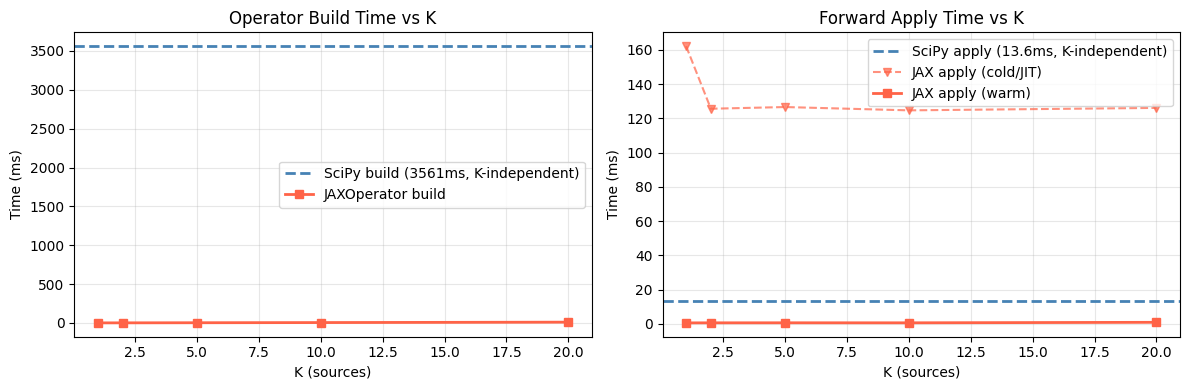

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Build time — JAX only (SciPy is constant, shown as reference line)
ax1.axhline(t_build_scipy_once * 1e3, color='steelblue', linestyle='--',
            label=f'SciPy build ({t_build_scipy_once*1e3:.0f}ms, K-independent)', lw=2)
ax1.plot(ks, [t*1e3 for t in bench['t_build_jax']], 's-', color='tomato', label='JAXOperator build', lw=2)
ax1.set_xlabel('K (sources)')
ax1.set_ylabel('Time (ms)')
ax1.set_title('Operator Build Time vs K')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Apply time
ax2.axhline(bench['t_apply_scipy'][0]*1e3, color='steelblue', linestyle='--',
            label=f'SciPy apply ({bench["t_apply_scipy"][0]*1e3:.1f}ms, K-independent)', lw=2)
ax2.plot(ks, [t*1e3 for t in bench['t_apply_jax_cold']], 'v--', color='tomato',
         label='JAX apply (cold/JIT)', lw=1.5, alpha=0.7)
ax2.plot(ks, [t*1e3 for t in bench['t_apply_jax_warm']], 's-', color='tomato',
         label='JAX apply (warm)', lw=2)
ax2.set_xlabel('K (sources)')
ax2.set_ylabel('Time (ms)')
ax2.set_title('Forward Apply Time vs K')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Section 3: Solve Time and Convergence

Fixed problem: K=5 sources, same `IMAGE_SHAPE=(500,20)` scene.

- **SpectralSolver (LSQR)**: solved with `scipy.sparse.linalg.lsqr`; residual
  norm tracked every 10 iterations via the `iter_lim` parameter.
- **JAXProximalSolver (FISTA)**: FISTA with group-L1; residual tracked every
  iteration. First call (JIT compile) excluded from steady-state timing.

The plot shows residual norm vs cumulative wall-clock time, illustrating the
JIT amortisation break-even point.

In [10]:
import scipy.sparse.linalg as spla

K_CONV = 5
src_pos_conv = np.column_stack([
    RNG.integers(0, N_ROWS, size=K_CONV),
    RNG.integers(0, N_COLS, size=K_CONV),
]).astype(np.float64)

# Reuse the already-built SciPySparseOperator
scipy_op_conv = scipy_op_bench
jax_op_conv   = JAXOperator.build(config, basis, IMAGE_SHAPE, src_pos_conv)

# Ground truth and noisy observation
a_true_conv = RNG.standard_normal(K_CONV * M)
f_clean_conv = jax_op_conv.apply(a_true_conv).reshape(IMAGE_SHAPE)
f_noisy_conv = NOISE_MODEL.sample(f_clean_conv, np.random.default_rng(99))
f_flat_conv  = f_noisy_conv.ravel()

# Precision weights
w = NOISE_MODEL.precision_weights(f_noisy_conv).ravel()

# Support mask: restrict LSQR to coefficients at known source pixel positions
src_flat_conv = [
    int(round(r)) * N_COLS + int(round(c))
    for r, c in src_pos_conv
]
# SciPySparseOperator H has shape (N_PIX, N_PIX*M)
# Select columns corresponding to the K source pixels
mask_cols = np.zeros(N_PIX * M, dtype=bool)
for p in src_flat_conv:
    mask_cols[p * M : (p + 1) * M] = True

print(f'Setup done. Active support columns: {mask_cols.sum()} / {N_PIX * M}')
print(f'f_clean max={f_clean_conv.max():.4f}, f_noisy range=[{f_noisy_conv.min():.2f}, {f_noisy_conv.max():.2f}]')


Setup done. Active support columns: 50 / 100000
f_clean max=24976.8418, f_noisy range=[-14774.79, 24845.17]


### LSQR Convergence (checkpoint every 10 iterations)

In [11]:
# Build weighted system A = diag(w) @ H_support, b = diag(w) @ f
H_support = scipy_op_conv._H[:, mask_cols]
WH = H_support.multiply(w[:, None])   # element-wise row scaling
Wf = w * f_flat_conv

MAX_LSQR_ITER = 300
CHUNK = 10
lsqr_times = []
lsqr_residuals = []
x_lsqr = np.zeros(H_support.shape[1])
t_lsqr_start = time.perf_counter()

for chunk_start in range(0, MAX_LSQR_ITER, CHUNK):
    result = spla.lsqr(
        WH, Wf,
        x0=x_lsqr,
        iter_lim=CHUNK,
        atol=0, btol=0, conlim=0,
    )
    x_lsqr = result[0]
    r_norm = float(np.linalg.norm(Wf - WH @ x_lsqr))
    elapsed = time.perf_counter() - t_lsqr_start
    lsqr_times.append(elapsed)
    lsqr_residuals.append(r_norm)

print(f'LSQR: {MAX_LSQR_ITER} iters, final residual={lsqr_residuals[-1]:.4f}')


LSQR: 300 iters, final residual=93.4610


### FISTA Convergence (per-iteration residual)

In [12]:
# FISTA warm-up (JIT compile)
_ = JAXProximalSolver(
    jax_op_conv, noise_model=NOISE_MODEL, lam=0.05, max_iter=1
).solve(f_noisy_conv)

# FISTA with per-iteration residual tracking
import jax.numpy as jnp
from spectrex.jax_solver import group_soft_threshold, power_iteration

N_FISTA_ITER = 200
LAM = 0.05

# power_iteration expects flat 1D precision_weights
L = power_iteration(jax_op_conv, w, N_PIX, n_iter=30)
step = 1.0 / max(L, 1e-10)

# Manual FISTA loop with timing
x = np.zeros(K_CONV * M)
y = x.copy()
t_fista_iter = 1.0

fista_times = []
fista_residuals = []
t_fista_start = time.perf_counter()

for i in range(1, N_FISTA_ITER + 1):
    # Gradient: H^T W^2 (Hx - f)
    Hx = jax_op_conv.apply(y).ravel()
    grad = jax_op_conv.apply_adjoint((Hx - f_flat_conv) * w**2)
    x_new = group_soft_threshold(y - step * grad, LAM * step, K_CONV, M)
    t_new = (1 + np.sqrt(1 + 4 * t_fista_iter**2)) / 2
    y = x_new + ((t_fista_iter - 1) / t_new) * (x_new - x)
    x, t_fista_iter = x_new, t_new
    r = float(np.linalg.norm(jax_op_conv.apply(x).ravel() - f_flat_conv))
    elapsed = time.perf_counter() - t_fista_start
    fista_times.append(elapsed)
    fista_residuals.append(r)

print(f'FISTA: {N_FISTA_ITER} iters, final residual={fista_residuals[-1]:.4f}')


FISTA: 200 iters, final residual=1028.3628


### Residual Norm vs Wall-Clock Time

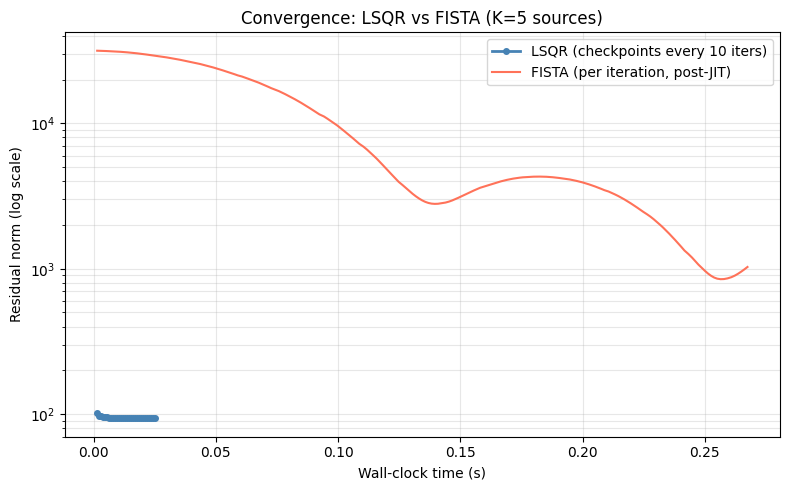


JIT amortisation: FISTA warm-up run excluded from timing above.
For 200 full solves, JIT overhead is negligible.


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(lsqr_times, lsqr_residuals, 'o-', color='steelblue',
            label='LSQR (checkpoints every 10 iters)', lw=2, markersize=4)
ax.semilogy(fista_times, fista_residuals, '-', color='tomato',
            label='FISTA (per iteration, post-JIT)', lw=1.5, alpha=0.9)
ax.set_xlabel('Wall-clock time (s)')
ax.set_ylabel('Residual norm (log scale)')
ax.set_title('Convergence: LSQR vs FISTA (K=5 sources)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()
print(f'\nJIT amortisation: FISTA warm-up run excluded from timing above.')
print(f'For {N_FISTA_ITER} full solves, JIT overhead is negligible.')


## Summary

| Metric | SciPySparseOperator / SpectralSolver | JAXOperator / JAXProximalSolver |
|--------|--------------------------------------|----------------------------------|
| Memory | O(**N_pix** × M) — all pixels | O(K × O × L + O × L × M) — **K sources only** |
| Weights stored | All N_pix × M (per-pixel) | O × L × M (**shared across K**) |
| Apply (warm) | CSR matvec | JIT-compiled einsum + scatter |
| Solver | LSQR (unconstrained) | FISTA group-L1 (sparse, per-source) |

**When to use which:**
- `SciPySparseOperator` + `SpectralSolver`: small images, CPU-only, no JAX, or fast
  prototyping with very few sources.
- `JAXOperator` + `JAXProximalSolver`: large images, many sources, GPU-available,
  or whenever accuracy in crowded fields matters.